<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA_ANDRES_DL_TP3_Co24_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

## 0 Data & Functions

### 0.1 Imports

In [30]:
# Librerias

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
import zipfile
import os
import random
import time
import pickle
import cv2
from PIL import Image

from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# !pip install wandb -qU
import wandb # Weights and Biases
from google.colab import userdata
wandb_key = userdata.get('WANDB_API_KEY')
wandb.login(key=wandb_key)


# --- REPRODUCIBILIDAD ---
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Asegurar resultados consistentes en convoluciones de cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


### 0.2 Funciones auxiliares

In [3]:
# ------------------------------------------------------------------
# GENERADOR DE EXPERIMENTOS
# ------------------------------------------------------------------

def ejecutar_bateria_experimentos(nombre_grupo, dataloader_train, dataloader_test, config_extra=None, arquitecturas=None, transformaciones_str=""):
    """
    Ejecuta una batería de entrenamientos para las arquitecturas dadas
    y loguea los resultados en Weights & Biases.
    """
    if config_extra is None:
        config_extra = {}

    if arquitecturas is None:
        arquitecturas = {
            "small": [16, 32, 64]
        }

    num_epochs = config_extra.get("epochs", 100)
    patience = config_extra.get("patience", 7)
    learning_rate = config_extra.get("learning_rate", 0.001)

    print(f"Iniciando batería de entrenamientos: {nombre_grupo}...\n")

    for tamano, config_arq in arquitecturas.items():
        # Lógica para soportar el formato antiguo (lista) o el nuevo (diccionario)
        if isinstance(config_arq, list):
            lista_filtros = config_arq
            lista_kernels = [3] * len(lista_filtros)
            fc_mode = 'standard'
        else:
            lista_filtros = config_arq.get("filtros", [16, 32, 64])
            lista_kernels = config_arq.get("kernels", [3] * len(lista_filtros))
            fc_mode = config_arq.get("fc_mode", "standard")

        nombre_corrida = f"{nombre_grupo}_{tamano}"
        print("="*60)
        print(f"EXPERIMENTO: {nombre_corrida} | Filtros: {lista_filtros} | Kernels: {lista_kernels} | FC: {fc_mode.upper()}")
        print("="*60)

        modelo = EmotionCNN(filtros=lista_filtros, kernels=lista_kernels, fc_mode=fc_mode).to(device)
        criterion = nn.CrossEntropyLoss()

        # Calculamos la cantidad total de parámetros entrenables
        total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
        print(f"Total de parámetros entrenables: {total_params:,}")

        optimizer = optim.Adam(modelo.parameters(), lr=learning_rate, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        best_test_loss = float('inf')
        epochs_no_improve = 0
        best_epoch = 0
        best_metrics = {}
        run_metrics_history = []

        # Unificar configuración base con la extra
        config_wandb = {
            "epochs": num_epochs,
            "patience": patience,
            "learning_rate": learning_rate,
            "filtros": lista_filtros,
            "kernels": lista_kernels,
            "fc_mode": fc_mode,
            "total_parametros": total_params,
            "batch_size": 64,
            "oversampling": True,
            "grupo": nombre_grupo,
            "transformaciones": transformaciones_str
        }
        config_wandb.update(config_extra)

        wandb.init(
            project="tp3-clasificador-emociones",
            name=nombre_corrida,
            group=nombre_grupo,
            config=config_wandb
        )

        for epoch in range(num_epochs):
            start_time = time.time()

            # --- FASE DE ENTRENAMIENTO ---
            modelo.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            all_train_preds = []
            all_train_labels = []

            for inputs, labels in dataloader_train:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = modelo(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

                all_train_preds.extend(predicted.cpu().numpy())
                all_train_labels.extend(labels.cpu().numpy())

            epoch_train_loss = running_loss / len(dataloader_train.dataset)
            epoch_train_acc = correct_train / total_train
            epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

            # --- FASE DE TEST ---
            modelo.eval()
            running_test_loss = 0.0
            correct_test = 0
            total_test_loop = 0
            all_test_preds = []
            all_test_labels = []

            with torch.no_grad():
                for inputs, labels in dataloader_test:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = modelo(inputs)
                    loss = criterion(outputs, labels)

                    running_test_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    total_test_loop += labels.size(0)
                    correct_test += (predicted == labels).sum().item()

                    all_test_preds.extend(predicted.cpu().numpy())
                    all_test_labels.extend(labels.cpu().numpy())

            epoch_test_loss = running_test_loss / len(dataloader_test.dataset)
            epoch_test_acc = correct_test / total_test_loop
            epoch_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

            # Actualiza el learning rate si no hay mejoras
            scheduler.step(epoch_test_loss)

            end_time = time.time()
            print(f"Ep {epoch+1:02d} | Tiempo: {end_time - start_time:.1f}s | Tr_Loss: {epoch_train_loss:.4f} | Tr_Acc: {epoch_train_acc:.4f} | Te_Loss: {epoch_test_loss:.4f} | Te_Acc: {epoch_test_acc:.4f} | Te_F1: {epoch_test_f1:.4f}")

            # Guardamos las métricas temporalmente (SIN LOGUEAR AÚN)
            metricas_epoca = {
                "epoch": epoch + 1,
                "train_loss": round(epoch_train_loss, 2),
                "train_acc": round(epoch_train_acc, 2),
                "train_f1_macro": round(epoch_train_f1, 2),
                "test_loss": round(epoch_test_loss, 2),
                "test_acc": round(epoch_test_acc, 2),
                "test_f1_macro": round(epoch_test_f1, 2)
            }
            run_metrics_history.append(metricas_epoca)

            # --- EARLY STOPPING ---
            if epoch_test_loss < best_test_loss:
                best_test_loss = epoch_test_loss
                epochs_no_improve = 0
                best_epoch = epoch + 1
                best_metrics = metricas_epoca
                torch.save(modelo.state_dict(), f'best_model_{nombre_corrida}.pth')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"-> EarlyStopping disparado tras {epoch+1} épocas.")
                    break

        # --- FINALIZACIÓN DE LA CORRIDA ---
        print(f"\nCargando los pesos del mejor modelo (Época {best_epoch}) para {nombre_corrida}...")
        modelo.load_state_dict(torch.load(f'best_model_{nombre_corrida}.pth'))

        print(f"Logueando métricas en W&B SOLAMENTE hasta la mejor época ({best_epoch})...")
        for metricas in run_metrics_history[:best_epoch]:
            wandb.log(metricas)

        if wandb.run is not None:
            # Actualizar el summary del run con los mejores valores
            for key, val in best_metrics.items():
                wandb.run.summary[key] = val

            # Aseguramos que el total de parámetros quede registrado en el summary
            wandb.run.summary["total_parametros"] = total_params

            # Subir los pesos del modelo a wandb
            wandb.save(f'best_model_{nombre_corrida}.pth')

        wandb.finish()
        print(f"¡Entrenamiento de {nombre_corrida} finalizado!\n")

    print(f"¡TODOS LOS EXPERIMENTOS DE {nombre_grupo} HAN FINALIZADO!")


In [18]:
# ------------------------------------------------------------------
# VISUALIZADOR DE DISTRIBUCIÓN DE CLASES
# ------------------------------------------------------------------
def plot_class_distribution(show_test=True):
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    print("Calculando distribución de clases...")

    # Conteo de imágenes por clase en Train
    train_counts = {c: len(os.listdir(os.path.join(DATASET_ROOT_TRAIN, c)))
                    for c in sorted(os.listdir(DATASET_ROOT_TRAIN))
                    if os.path.isdir(os.path.join(DATASET_ROOT_TRAIN, c))}

    sns.set_theme(style="whitegrid")

    if show_test:
        # Conteo de imágenes por clase en Test
        test_counts = {c: len(os.listdir(os.path.join(DATASET_ROOT_TEST, c)))
                       for c in sorted(os.listdir(DATASET_ROOT_TEST))
                       if os.path.isdir(os.path.join(DATASET_ROOT_TEST, c))}

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Gráfico para Train
        sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()),
                    ax=axes[0], hue=list(train_counts.keys()), palette="Blues_r", legend=False)
        axes[0].set_title(f'Distribución de Clases - TRAIN (Total: {sum(train_counts.values())})')
        axes[0].set_ylabel('Cantidad de Imágenes')
        axes[0].set_xlabel('Emoción')
        axes[0].tick_params(axis='x', rotation=45)

        # Gráfico para Test
        sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()),
                    ax=axes[1], hue=list(test_counts.keys()), palette="Reds_r", legend=False)
        axes[1].set_title(f'Distribución de Clases - TEST (Total: {sum(test_counts.values())})')
        axes[1].set_ylabel('Cantidad de Imágenes')
        axes[1].set_xlabel('Emoción')
        axes[1].tick_params(axis='x', rotation=45)

    else:
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
        sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()),
                    ax=ax, hue=list(train_counts.keys()), palette="Blues_r", legend=False)
        ax.set_title(f'Distribución de Clases - TRAIN (Total: {sum(train_counts.values())})')
        ax.set_ylabel('Cantidad de Imágenes')
        ax.set_xlabel('Emoción')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [22]:

# ------------------------------------------------------------------
# VISUALIZADOR DE HISTORIAL DE W&B
# ------------------------------------------------------------------
def plot_wandb_history(run_buscado, project_name="tp3-clasificador-emociones"):
    import wandb
    import matplotlib.pyplot as plt
    import seaborn as sns

    api = wandb.Api()
    try:
        # Busca las corridas en el proyecto
        runs = api.runs(project_name)
        run_seleccionado = None

        # Buscamos si hay alguna corrida con ese nombre o ID
        for run in runs:
            if run.name == run_buscado or run.id == run_buscado or run_buscado in run.name:
                run_seleccionado = run
                break

        # Si no la encuentra, mostramos un listado de ayuda
        if run_seleccionado is None:
            print(f"⚠️ No se encontró la corrida con nombre/ID '{run_buscado}'.")
            print("Las últimas corridas disponibles en tu proyecto son:")
            for r in runs[:5]:
                print(f" - Nombre: {r.name} | ID: {r.id}")

            # Usamos la más reciente como fallback
            if len(runs) > 0:
                run_seleccionado = runs[0]
                print(f"\nGraficando por defecto la más reciente: {run_seleccionado.name}...")
        else:
            print(f"✅ Graficando datos de la corrida: {run_seleccionado.name}")

        if run_seleccionado:
            # Descargamos el historial en formato DataFrame de Pandas
            history = run_seleccionado.history()

            if 'epoch' in history.columns:
                sns.set_theme(style="whitegrid")
                fig, axes = plt.subplots(1, 3, figsize=(18, 5))

                # Gráfico de Loss
                if 'train_loss' in history.columns and 'test_loss' in history.columns:
                    axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', markersize=4)
                    axes[0].plot(history['epoch'], history['test_loss'], label='Test Loss', marker='o', markersize=4)
                    axes[0].set_title('Evolución del Costo (Loss)')
                    axes[0].set_xlabel('Época')
                    axes[0].set_ylabel('Loss')
                    axes[0].legend()

                # Gráfico de F1-Score
                if 'train_f1_macro' in history.columns and 'test_f1_macro' in history.columns:
                    axes[1].plot(history['epoch'], history['train_f1_macro'], label='Train F1 Macro', marker='o', markersize=4)
                    axes[1].plot(history['epoch'], history['test_f1_macro'], label='Test F1 Macro', marker='o', markersize=4)
                    axes[1].set_title('Evolución del F1-Score (Macro)')
                    axes[1].set_xlabel('Época')
                    axes[1].set_ylabel('F1-Score')
                    axes[1].legend()
                else:
                    print("No se encontraron métricas de F1 en el historial de esta corrida.")

                # Gráfico de Accuracy
                if 'train_acc' in history.columns and 'test_acc' in history.columns:
                    axes[2].plot(history['epoch'], history['train_acc'], label='Train Acc', marker='o', markersize=4)
                    axes[2].plot(history['epoch'], history['test_acc'], label='Test Acc', marker='o', markersize=4)
                    axes[2].set_title('Evolución del Accuracy')
                    axes[2].set_xlabel('Época')
                    axes[2].set_ylabel('Accuracy')
                    axes[2].legend()
                else:
                    print("No se encontraron métricas de Accuracy en el historial de esta corrida.")

                plt.tight_layout()
                plt.show()
            else:
                print("No se encontraron datos de épocas en esta corrida.")
    except Exception as e:
        print(f"Ocurrió un error al intentar acceder a W&B: {e}")


### 0.3 Data Load

In [5]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_TEST  = '/content/datos_zip/dataset_emociones/validation' # Lo usaremos como TEST

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=a182ac1c-c2c0-4caf-985d-e81fed8a58ae
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 68.9MB/s]


--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- TEST ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Test: 3068
Calculando distribución de clases...


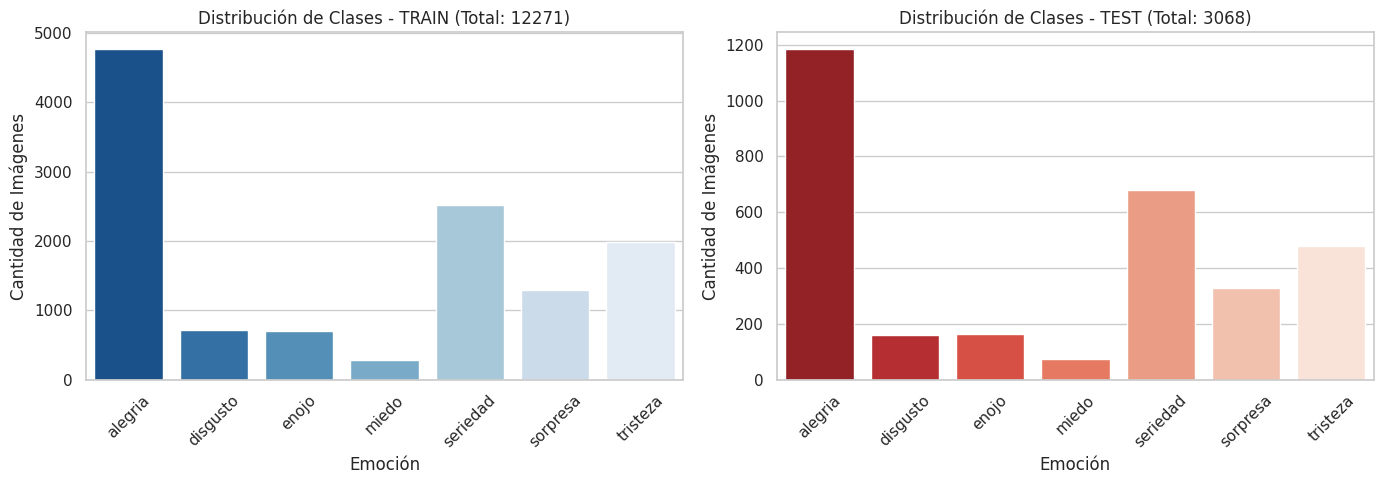

In [8]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- TEST ---")
test_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TEST)):
    ruta_clase = os.path.join(DATASET_ROOT_TEST, clase)
    if os.path.isdir(ruta_clase):
        test_counts[clase] = len(os.listdir(ruta_clase))

total_test = sum(test_counts.values())
for clase, cantidad in test_counts.items():
    porcentaje = (cantidad / total_test) * 100 if total_test > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Test: {total_test}")


plot_class_distribution(show_test=True)

- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

## 1 Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



### 1.1 Visializador de Imagenes

--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
Opción 0 (o inválida). Clase elegida al azar.
--- METADATA DE LAS IMÁGENES (SORPRESA) ---
[1] Archivo: train_00673_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_06709_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_04503_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_07055_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


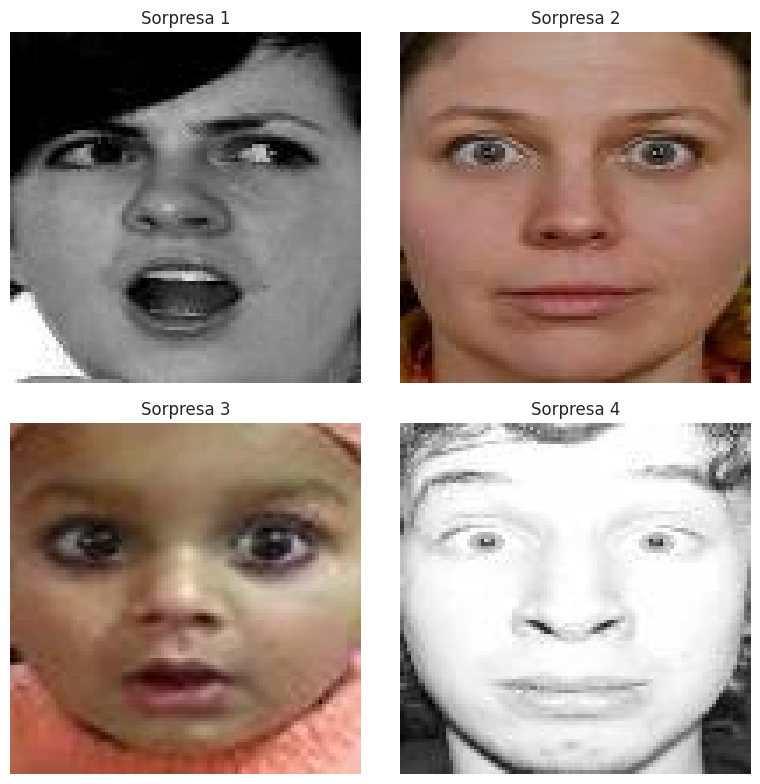

In [9]:
# VISUALIZADOR

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 0 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")


- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

### 1.2 Transformaciones y Data Agumentation

In [10]:
print("--- 1. ESTADÍSTICAS PARA 1 CANAL (ESCALA DE GRISES) ---")
# Valores pre-calculados para el dataset de entrenamiento (1 canal)
MEAN = [0.4816167652606964]
STD = [0.5369674563407898]

print(f"Mean (Media) hardcodeada: {MEAN}")
print(f"Std (Desviación) hardcodeada: {STD}\n")

print("--- 2. CREANDO DATALOADERS FINALES ---")
# Transformaciones finales incluyendo la normalización
transforms_norm = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Grayscale(num_output_channels=1), # <-- Aseguramos 1 canal
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)     # <-- Normalización con valores fijos
])

# Datasets finales únicos
train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_norm)
test_dataset = datasets.ImageFolder(root=DATASET_ROOT_TEST, transform=transforms_norm)

# Calcular Pesos para el Sampler (Oversampling)
targets = train_dataset.targets
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

# Aplicando Reproducibilidad al Dataloader
g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(targets), replacement=True, generator=g)

# Crear los DataLoaders Finales
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

print(f"Imágenes para entrenamiento: {len(train_dataset)} -> Batches: {len(train_loader)}")
print(f"Imágenes para test: {len(test_dataset)} -> Batches: {len(test_loader)}")


--- 1. ESTADÍSTICAS PARA 1 CANAL (ESCALA DE GRISES) ---
Mean (Media) hardcodeada: [0.4816167652606964]
Std (Desviación) hardcodeada: [0.5369674563407898]

--- 2. CREANDO DATALOADERS FINALES ---
Imágenes para entrenamiento: 12271 -> Batches: 192
Imágenes para test: 3068 -> Batches: 48


### 1.3 Conclusiones

- **Class Imbalance**: Utilicé `WeightedRandomSampler` para hacer oversampling de las clases minoritarias durante el entrenamiento.
- **Escala de grises (1 Canal)**: Convertí todo a blanco y negro. El color no me aporta información extra para clasificar emociones y me permite diseñar una red más liviana y rápida de entrenar.
- **Normalización**: Estandaricé los tensores usando la media y desviación estándar calculadas sobre mi set de train (previamente calculado).
- **Horizontal Flip**: `RandomHorizontalFlip` ya que los rostros son simétricos respecto a las expresiones.
- **Rotación**: Sumé rotaciones leves (`RandomRotation`) para forzar al modelo a ser invariante a la inclinación de la cabeza (muy común en fotos reales).
- **Color Jitter**: Agregué variaciones de brillo y contraste (`ColorJitter`) para que la red aprenda a generalizar bajo distintas condiciones de iluminación.
- **Gaussian Blur**: Apliqué desenfoque gaussiano (`GaussianBlur`) para simular fotos movidas o cámaras fuera de foco. Esto evita que el modelo dependa de bordes perfectos y lo hace más robusto ante imágenes de menor calidad. Habia bastantes en el set de train.
- **Perspectiva Aleatoria**: Sumé `RandomPerspective` para simular distintos ángulos.
- **Traslación y Escala (Affine)**: Agregué `RandomAffine` con ligeras traslaciones y zoom.
- **Oclusión (Random Erasing)**: Apliqué `RandomErasing` para simular rostros parcialmente tapados, obligando a la red a extraer características de todo el rostro y no depender de un solo rasgo.

## 2 Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [11]:
# Bloque de convolución para emplear en la red
def conv_block(c_in, c_out, k=3, p=1, s=1, pk=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        # nn.BatchNorm2d(c_out), # <-- Desactivado temporalmente
        nn.ReLU(),
        nn.MaxPool2d(pk)
    )

class EmotionCNN(nn.Module):
    def __init__(self, filtros=[16, 32, 64], kernels=None, fc_mode='standard'):
        super(EmotionCNN, self).__init__()

        # Si no se pasan kernels, por defecto usamos 3x3 en todas las capas
        if kernels is None:
            kernels = [3] * len(filtros)

        layers = []
        in_channels = 1 # Imágenes en escala de grises (1 canal)

        # Construcción dinámica de capas con kernels específicos
        for out_channels, k_size in zip(filtros, kernels):
            pad = k_size // 2  # Padding automático para no perder dimensiones espaciales extra
            layers.append(conv_block(in_channels, out_channels, k=k_size, p=pad))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calcular automáticamente el tamaño de la imagen tras los MaxPool2d
        dim = 100
        for _ in filtros:
            dim = dim // 2

        flatten_size = filtros[-1] * dim * dim

        # Selección de la arquitectura de la capa densa (Fully Connected)
        if fc_mode == 'standard':
            # Clasificador ORIGINAL
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flatten_size, 512),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(512, 7)      # 7 clases de emociones
            )
        elif fc_mode == 'deep':
            # Más capas, menos neuronas, Dropouts progresivos
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flatten_size, 256),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 7)
            )
        else:
            raise ValueError("fc_mode no reconocido. Usa 'standard' o 'deep'")

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nModelo base listo para instanciar en el dispositivo: {device}")
print("Arquitectura actualizada: Permite configurar dinámicamente tamaños de Kernel y la profundidad de la capa FC.")



Modelo base listo para instanciar en el dispositivo: cpu
Arquitectura actualizada: Permite configurar dinámicamente tamaños de Kernel y la profundidad de la capa FC.


### 2.1 Baseline (1ch, WRS, Norm, small)

In [ ]:
# ==================================================================
# EJECUCIÓN DEL NUEVO BASELINE
# ==================================================================

# config_baseline = {
#     "data_augmentation": False,
#     "da_technique": "None (Only Norm + 1CH)"
# }
#
# ejecutar_bateria_experimentos(
#     nombre_grupo="Baseline_1CH_WRS",
#     dataloader_train=train_loader,
#     dataloader_test=test_loader,
#     config_extra=config_baseline
# )

### 2.2 Data Augmentation: RandomHorizontalFlip

In [ ]:
# # ==================================================================
# # 2.2 Data Augmentation: RandomHorizontalFlip
# # ==================================================================

# print("--- PREPARANDO DATALOADER CON HORIZONTAL FLIP ---")

# # 1. Definimos las transformaciones AÑADIENDO RandomHorizontalFlip
# transforms_hflip = transforms.Compose([
#     transforms.Resize((100, 100)),
#     transforms.RandomHorizontalFlip(p=0.5),      # <-- NUEVA TRANSFORMACIÓN
#     transforms.Grayscale(num_output_channels=1),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=MEAN, std=STD)
# ])

# # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
# train_dataset_hflip = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_hflip)

# # 3. Creamos el nuevo DataLoader de entrenamiento manteniendo el mismo Sampler para las clases
# train_loader_hflip = DataLoader(train_dataset_hflip, batch_size=batch_size, sampler=sampler)

# # 4. Configuración extra para guardar en Weights & Biases
# config_hflip = {
#     "data_augmentation": True,
#     "da_technique": "RandomHorizontalFlip (p=0.5)"
# }

# # 5. Definimos las 3 arquitecturas para probar en este experimento
# arquitecturas_todas = {
#     "small": [16, 32, 64],
#     "mid": [32, 64, 128],
#     "large": [64, 128, 256]
# }

# # 6. Ejecutamos pasándole el nuevo loader de train y el loader de test original
# ejecutar_bateria_experimentos(
#     nombre_grupo="Exp_HorizontalFlip",
#     dataloader_train=train_loader_hflip,
#     dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#     config_extra=config_hflip,
#     arquitecturas=arquitecturas_todas
# )

### 2.3 Data Augmentation: RandomRotation

In [ ]:
# # ==================================================================
# # 2.3 Data Augmentation: RandomRotation
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM ROTATION ---")

# # Definimos los grados que queremos probar
# grados_a_probar = [10, 20, 30]

# # Fijamos la arquitectura solo a 'small'
# arq_small = {
#     "small": [16, 32, 64]
# }

# for grados in grados_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON ROTACIÓN: ±{grados} GRADOS <<<")

#     # 1. Definimos las transformaciones AÑADIENDO RandomRotation
#     transforms_rotation = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomRotation(degrees=grados),       # <-- VARIAMOS LOS GRADOS
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_rotation = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_rotation)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_rotation = DataLoader(train_dataset_rotation, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_rotation = {
#         "data_augmentation": True,
#         "da_technique": f"RandomRotation (degrees={grados})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo=f"Exp_RandomRotation_{grados}deg",
#         dataloader_train=train_loader_rotation,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_rotation,
#         arquitecturas=arq_small
#     )

### 2.4 Data Augmentation: ColorJitter (Brillo y Contraste)

In [ ]:
# # ==================================================================
# # 2.4 Data Augmentation: ColorJitter
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON COLOR JITTER ---")

# # Definimos las intensidades (10%, 20% y 30% de variación)
# intensidades_a_probar = [0.1, 0.2, 0.3]

# for intensidad in intensidades_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON COLOR JITTER: Intensidad {intensidad} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_{intensidad}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO ColorJitter
#     transforms_jitter = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.ColorJitter(brightness=intensidad, contrast=intensidad), # <-- VARIAMOS LA ILUMINACIÓN
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_jitter = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_jitter)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_jitter = DataLoader(train_dataset_jitter, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_jitter = {
#         "data_augmentation": True,
#         "da_technique": f"ColorJitter (b={intensidad}, c={intensidad})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Color_Jitter",  # <-- MISMO GRUPO PARA TODAS LAS INTENSIDADES
#         dataloader_train=train_loader_jitter,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_jitter,
#         arquitecturas=arq_small
#     )


### 2.5 Data Augmentation: Gaussian Blur (Imágenes movidas/desenfocadas)

In [ ]:
# # ==================================================================
# # 2.5 Data Augmentation: GaussianBlur
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON GAUSSIAN BLUR (IMÁGENES MOVIDAS) ---")

# # Definimos los tamaños del kernel a probar (mientras más grande, más borroso. Deben ser impares)
# kernels_a_probar = [3, 5, 7]

# for kernel in kernels_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON BLUR: Kernel {kernel}x{kernel} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_k{kernel}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO GaussianBlur
#     transforms_blur = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.GaussianBlur(kernel_size=kernel), # <-- SIMULAMOS EL DESENFOQUE/MOVIMIENTO
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_blur = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_blur)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_blur = DataLoader(train_dataset_blur, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_blur = {
#         "data_augmentation": True,
#         "da_technique": f"GaussianBlur (kernel_size={kernel})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Gaussian_Blur",  # <-- MISMO GRUPO PARA TODAS LAS INTENSIDADES
#         dataloader_train=train_loader_blur,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_blur,
#         arquitecturas=arq_small
#     )


### 2.6 Data Augmentation: Random Perspective

In [ ]:
# # ==================================================================
# # 2.6 Data Augmentation: RandomPerspective
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM PERSPECTIVE ---")

# # Definimos las escalas de distorsión a probar (valores bajos por ser rostros en primer plano)
# escalas_a_probar = [0.1, 0.2, 0.3]

# for escala in escalas_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON PERSPECTIVA: Distorsión {escala} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_dist{escala}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomPerspective
#     # p=1.0 fuerza la transformación para medir su impacto exacto en el experimento
#     transforms_perspective = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomPerspective(distortion_scale=escala, p=1.0), # <-- SIMULAMOS CAMBIO DE ÁNGULO
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_perspective = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_perspective)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_perspective = DataLoader(train_dataset_perspective, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_perspective = {
#         "data_augmentation": True,
#         "da_technique": f"RandomPerspective (scale={escala})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Perspective",  # <-- MISMO GRUPO PARA TODAS LAS ESCALAS
#         dataloader_train=train_loader_perspective,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_perspective,
#         arquitecturas=arq_small
#     )


### 2.7 Data Augmentation: Random Affine (Traslación y Escala)

In [ ]:
# # ==================================================================
# # 2.7 Data Augmentation: RandomAffine
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM AFFINE ---")

# # Probaremos distintas intensidades de traslación (1%, 3% y 5% del tamaño de la imagen)
# traslaciones_a_probar = [0.01, 0.03, 0.05]

# for traslacion in traslaciones_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON AFFINE: Traslación {int(traslacion*100)}% <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_affine_{traslacion}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomAffine
#     # Mantenemos degrees=0 porque ya probamos rotación sola.
#     # scale=(0.9, 1.1) aplica un leve zoom in/out aleatorio del 10%.
#     transforms_affine = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomAffine(degrees=0, translate=(traslacion, traslacion), scale=(0.9, 1.1)),
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_affine = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_affine)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_affine = DataLoader(train_dataset_affine, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_affine = {
#         "data_augmentation": True,
#         "da_technique": f"RandomAffine (trans={traslacion}, scale=0.9-1.1)"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Affine",
#         dataloader_train=train_loader_affine,
#         dataloader_test=test_loader,
#         config_extra=config_affine,
#         arquitecturas=arq_small
#     )


### 2.8 Data Augmentation: Random Erasing (Oclusión)

In [ ]:
# # ==================================================================
# # 2.8 Data Augmentation: RandomErasing (Oclusión)
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM ERASING ---")

# # Probaremos distintas probabilidades de que aparezca el parche (40%, 50% y 60%)
# probabilidades_a_probar = [0.4, 0.5, 0.6]

# for prob in probabilidades_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON ERASING: Probabilidad {int(prob*100)}% <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_erasing_{prob}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomErasing
#     # NOTA IMPORTANTE: RandomErasing trabaja sobre tensores, DEBE ir después de ToTensor()
#     transforms_erasing = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.RandomErasing(p=prob, scale=(0.02, 0.1)), # <-- Parche aleatorio que tapa entre 2% y 10% de la imagen
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_erasing = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_erasing)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_erasing = DataLoader(train_dataset_erasing, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_erasing = {
#         "data_augmentation": True,
#         "da_technique": f"RandomErasing (p={prob}, scale=0.02-0.1)"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Erasing",
#         dataloader_train=train_loader_erasing,
#         dataloader_test=test_loader,
#         config_extra=config_erasing,
#         arquitecturas=arq_small
#     )


### 2.9 Conclusiones
- Se realizaron experimentos con CNNs de tres capas, logueandose los resultados de todos los experimentos en W&B
- Se decidio optar por una red CNN de 3 capas (32, 64, 128), Kernell de 5, 5, 5, con unos 10,000 parametros entrenables en total
- Si bien se encontraron modelos mejores, los mismos eran mucho mas pesados (mas de 20,000 parametros entrenables), y la ganancia no era mucho mas que la obtenida con la arquitectura elegida
- Para la parte Fully Connected se suman otras 2 capas (256, 128) con 40% y 30% de dropout para evitar el overfitting
- Con respecto a las transformaciones, estan todas comentadas al final del punto 1

## 3 Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


In [13]:
# ==================================================================
# ENTRENAMIENTO DEL MODELO FINAL CON MEJORES HIPERPARÁMETROS
# ==================================================================
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import pickle
import numpy as np
import random

# Aseguramos estado antes del modelo final
set_seed(SEED)

print("--- ARMANDO PIPELINE DEL MODELO FINAL ---")

# Parámetros elegidos manualmente
best_rot = 10
best_jitter = 0.3
best_perspective = 0.05
best_affine = 0.05
best_erasing = 0.3

# 1. Definimos las transformaciones combinando todas las ganadoras
transforms_final = transforms.Compose([
    transforms.Resize((100, 100)),

    # Transformaciones espaciales y de color
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=best_rot),
    transforms.ColorJitter(brightness=best_jitter, contrast=best_jitter),
    transforms.RandomPerspective(distortion_scale=best_perspective, p=0.5),
    transforms.RandomAffine(degrees=0, translate=(best_affine, best_affine), scale=(0.9, 1.1)),

    # Conversión a grises y a Tensor
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),

    # Random Erasing (debe ir sobre el Tensor)
    transforms.RandomErasing(p=best_erasing, scale=(0.02, 0.1)),

    # Normalización estadística
    transforms.Normalize(mean=MEAN, std=STD)
])

# Reproducibilidad en el Dataloader Final
g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# 2. Aplicamos al dataset y creamos loader
train_dataset_final = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_final)
train_loader_final = DataLoader(train_dataset_final, batch_size=batch_size, sampler=sampler, worker_init_fn=seed_worker, generator=g)

# 3. Arquitecturas a probar: Entrenamos la nueva arquitectura
arquitecturas_fc = {
    "Final": {"filtros": [64, 128, 256], "kernels": [5, 5, 5], "fc_mode": "deep"}
}

config_final = {
    "data_augmentation": True,
    "da_technique": "Combinacion_Ganadores_Manual",
    "learning_rate": 0.0001,
    "epochs": 200,    # Entrenamiento exhaustivo
    "patience": 10,   # Margen al scheduler
    "seed": SEED      # Registramos la semilla en el experimento
}

# Convertimos las transformaciones a string para que quede registrado explícitamente en W&B
transforms_string = str(transforms_final)

# 4. Entrenamos la red
ejecutar_bateria_experimentos(
    nombre_grupo="Modelo",
    dataloader_train=train_loader_final,
    dataloader_test=test_loader,
    config_extra=config_final,
    arquitecturas=arquitecturas_fc,
    transformaciones_str=transforms_string
)

# Aca exportamos el modelo, para poder cargarlo despues en otra notebook
# 5. Exportar el modelo a un archivo Pickle
nombre_corrida = "Modelo_Final"
ruta_pth = f"best_model_{nombre_corrida}.pth"

# Instanciamos un nuevo modelo para cargar los mejores pesos guardados en la ejecución anterior
modelo_export = EmotionCNN(filtros=[64, 128, 256], kernels=[5, 5, 5], fc_mode="deep").to(device)
modelo_export.load_state_dict(torch.load(ruta_pth))

with open('modelo.pkl', 'wb') as f:
    pickle.dump(modelo_export, f)


In [21]:
# Aca cargamos el pickle del modelo

# Determinar automáticamente el dispositivo disponible (ahora será CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instanciamos la arquitectura EXACTA que se usó para entrenar el modelo final
# (Según la celda anterior: filtros=[64, 128, 256], kernels=[5, 5, 5], fc_mode="deep")
modelo = EmotionCNN(filtros=[64, 128, 256], kernels=[5, 5, 5], fc_mode="deep").to(device)

# 2. Cargamos los pesos desde el archivo .pth
# Tambien podriamos cargar el pickle, pero como ya no tenemos mas GPU conviene ek .pth
ruta_pth = 'best_model_Modelo_Final.pth'
# Usamos map_location=device para que PyTorch convierta los tensores de GPU a CPU sin errores
modelo.load_state_dict(torch.load(ruta_pth, map_location=device, weights_only=True))

# Configurar en modo evaluación por defecto para inferencia
modelo.eval()

# Preparar optimizador y loss por si se desea continuar entrenando
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.00005)

Evaluando el modelo final en el conjunto de Test...

--- RESULTADOS FINALES EN TEST ---
Test Loss: 0.6390
Test Accuracy: 0.7832
Test F1 Score (Macro): 0.7054

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     alegria       0.95      0.86      0.90      1185
    disgusto       0.40      0.55      0.46       160
       enojo       0.63      0.81      0.71       162
       miedo       0.55      0.62      0.59        74
    seriedad       0.76      0.74      0.75       680
    sorpresa       0.77      0.82      0.80       329
    tristeza       0.74      0.72      0.73       478

    accuracy                           0.78      3068
   macro avg       0.69      0.73      0.71      3068
weighted avg       0.80      0.78      0.79      3068



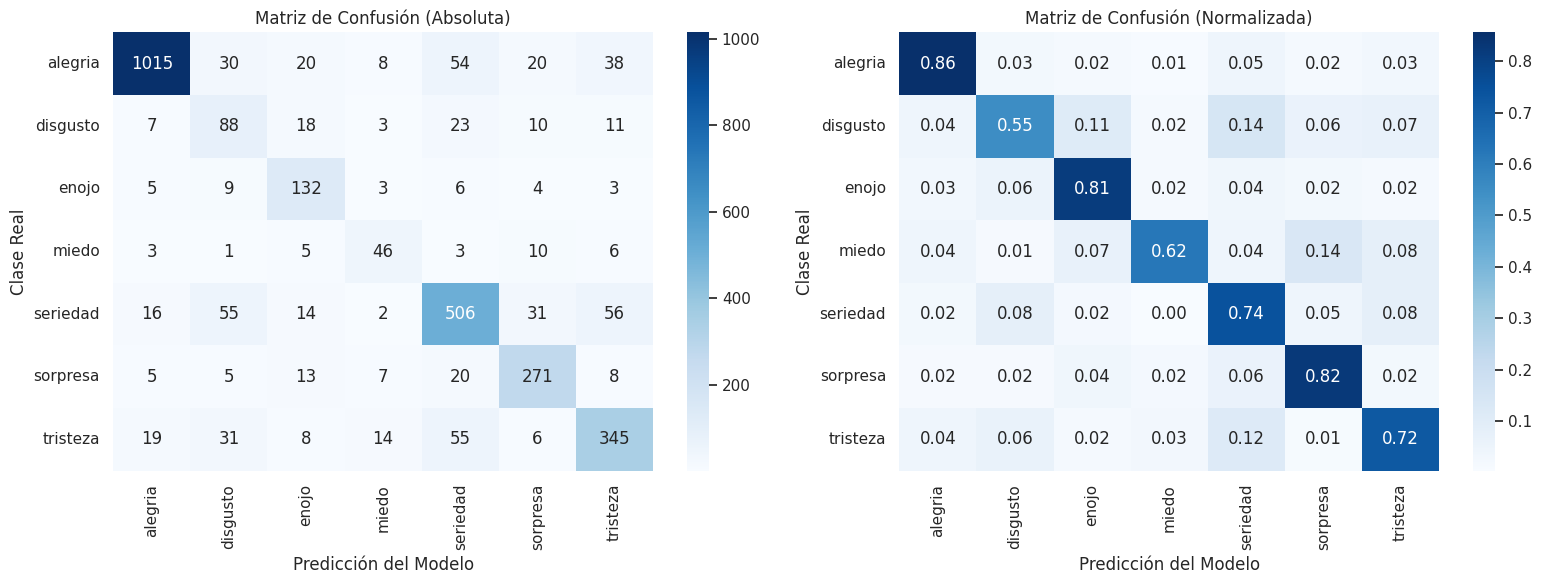

In [17]:
# Obtenemos los nombres de las clases
clases = test_dataset.classes

# Ponemos el modelo en modo evaluación
modelo.eval()
criterion = torch.nn.CrossEntropyLoss()

all_preds = []
all_labels = []
running_test_loss = 0.0

print("Evaluando el modelo final en el conjunto de Test...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = modelo(inputs)
        loss = criterion(outputs, labels)

        running_test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Cálculos de métricas globales
test_loss = running_test_loss / len(test_loader.dataset)
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"\n--- RESULTADOS FINALES EN TEST ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score (Macro): {test_f1:.4f}")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=clases))

# Cálculo de matrices de confusión
cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Matriz de Confusión Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases, ax=axes[0])
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Clase Real')

# 2. Matriz de Confusión Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=clases, yticklabels=clases, ax=axes[1])
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Clase Real')

plt.tight_layout()
plt.show()


Calculando distribución de clases...


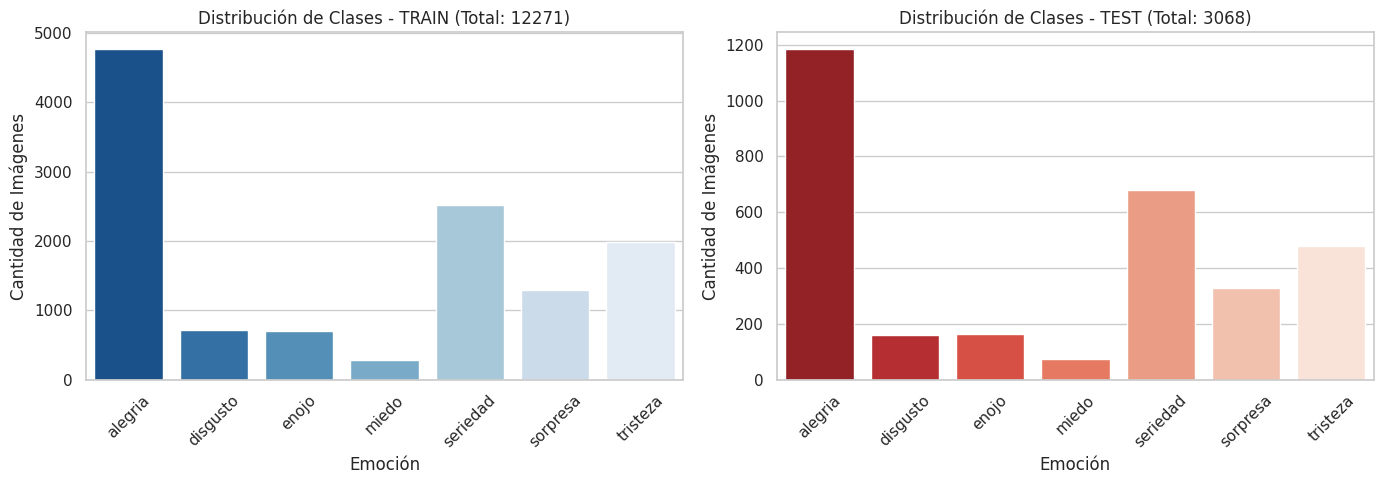

In [25]:
plot_class_distribution(show_test = True)

✅ Graficando datos de la corrida: Modelo_Final


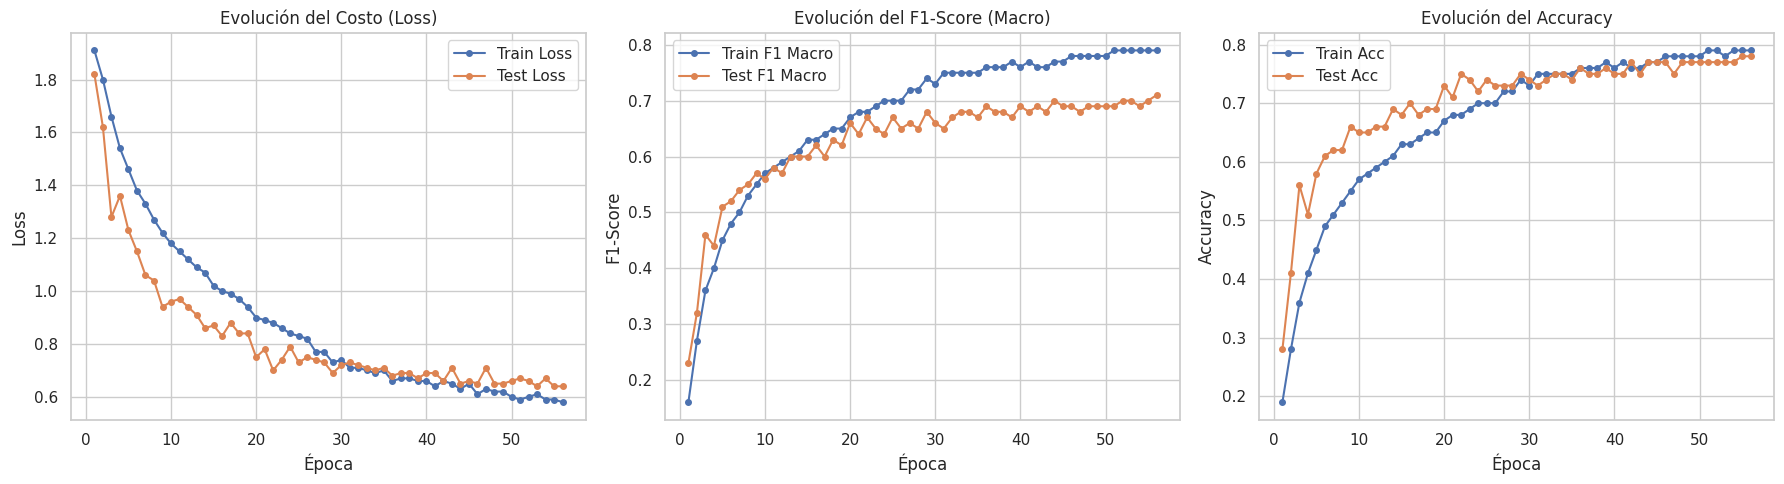

In [23]:
# Llamada a la función pasándole el ID o nombre de la corrida ganadora
plot_wandb_history(run_buscado="iq5ngnp5")


### 3.1 Conclusiones

- Correlación directa entre volumen de datos y rendimiento: El modelo aprende muy bien a predecir "alegría" (F1-score de 0.90) porque es la clase con más ejemplos. Inversamente, las clases minoritarias como "disgusto" (F1-score 0.46) y "miedo" (F1-score 0.59) son las que el modelo tiene más dificultades para predecir correctamente
- El Accuracy es una métrica engañosa aquí: El Accuracy general del 78% está inflado por el excelente rendimiento en la clase mayoritaria ("alegría"). El F1-Score Macro (71%) es un indicador mucho más realista del rendimiento real del modelo, ya que promedia el desempeño tratando a todas las clases por igual sin importar su tamaño
- Las confusiones son semánticamente coherentes. disgusto se confunde con seriedad y tristeza; miedo con sorpresa — pares de emociones que comparten rasgos faciales similares
- Se realizaron otros 100 experimentos mas, todos los resultados estan guardados en [W&B](https://api.wandb.ai/links/andresmontesdeoca/veg7w1z1)

 ## 4 Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

--- EVALUACIÓN DE IMÁGENES NUEVAS ---


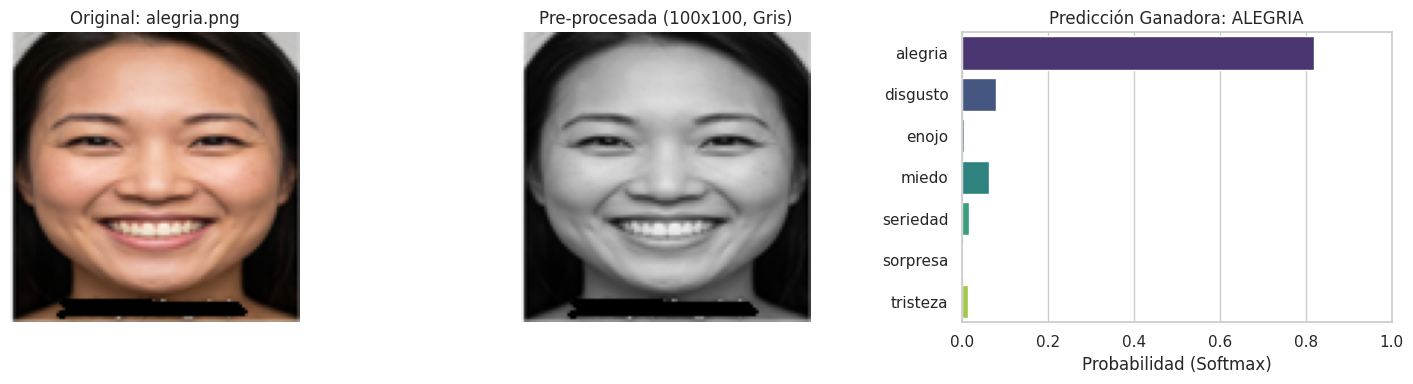

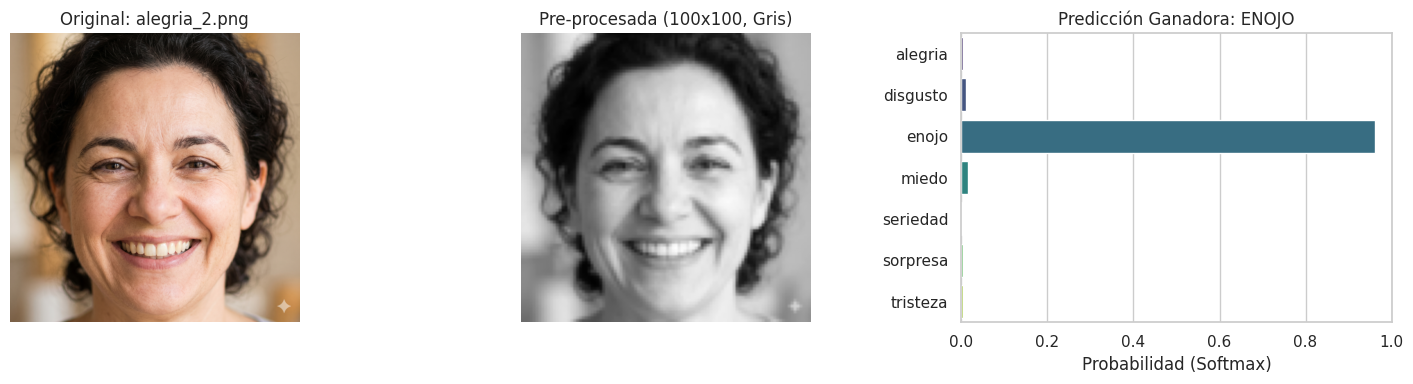

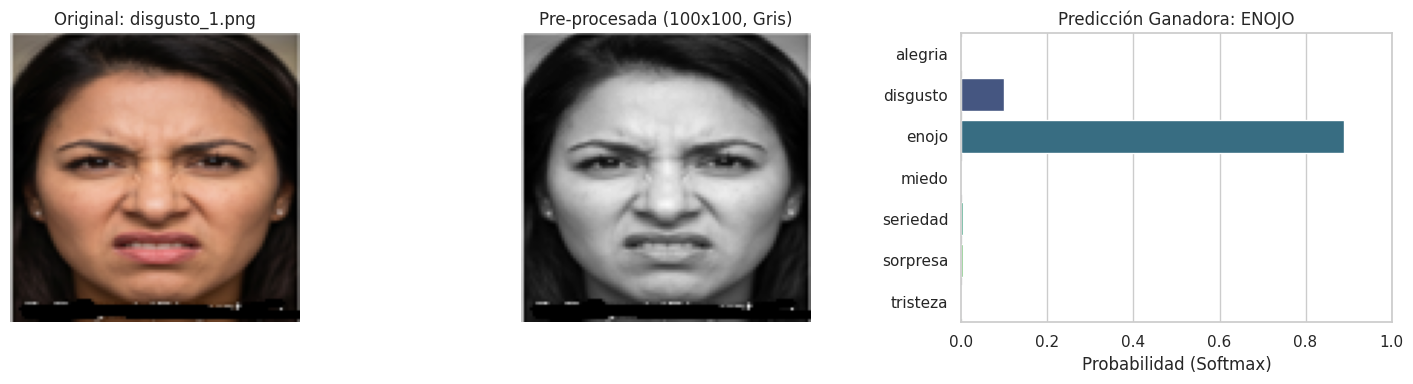

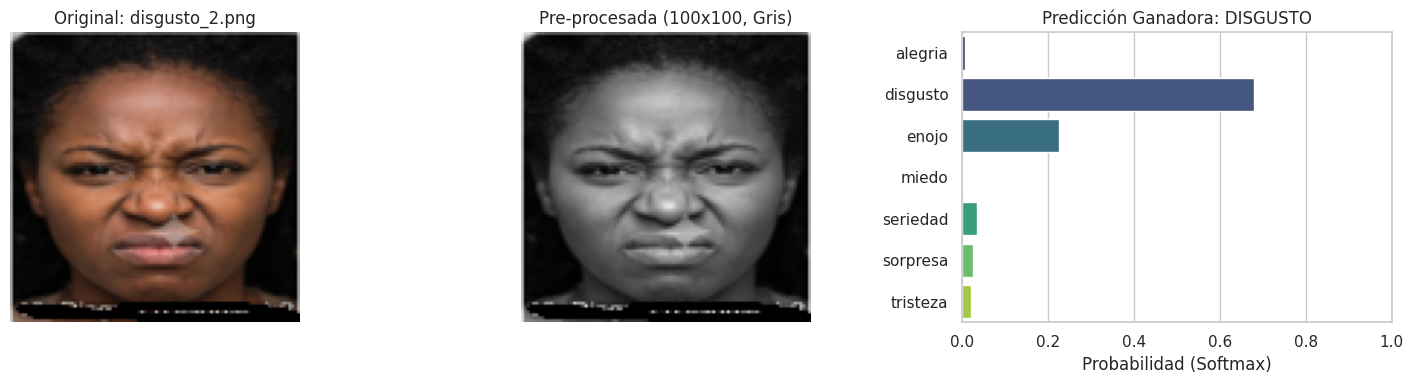

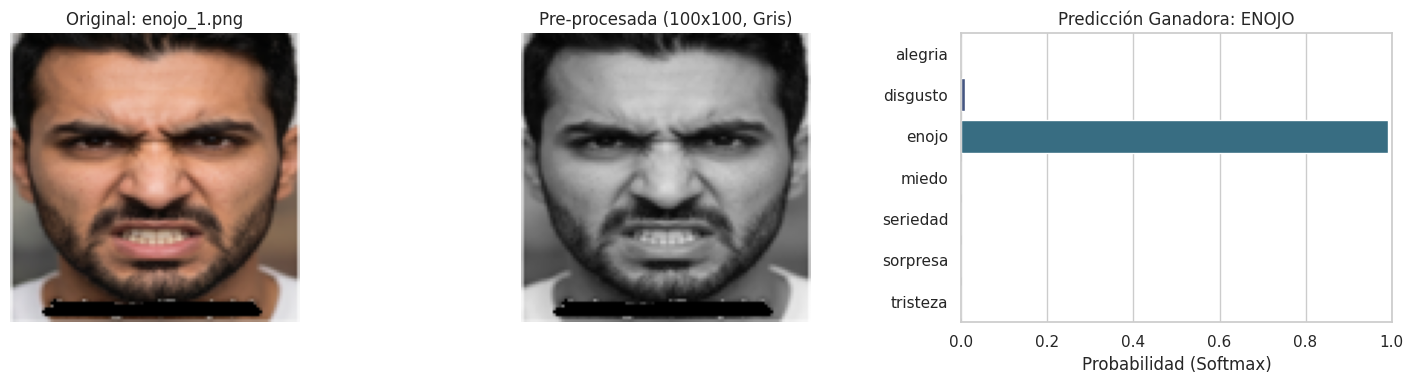

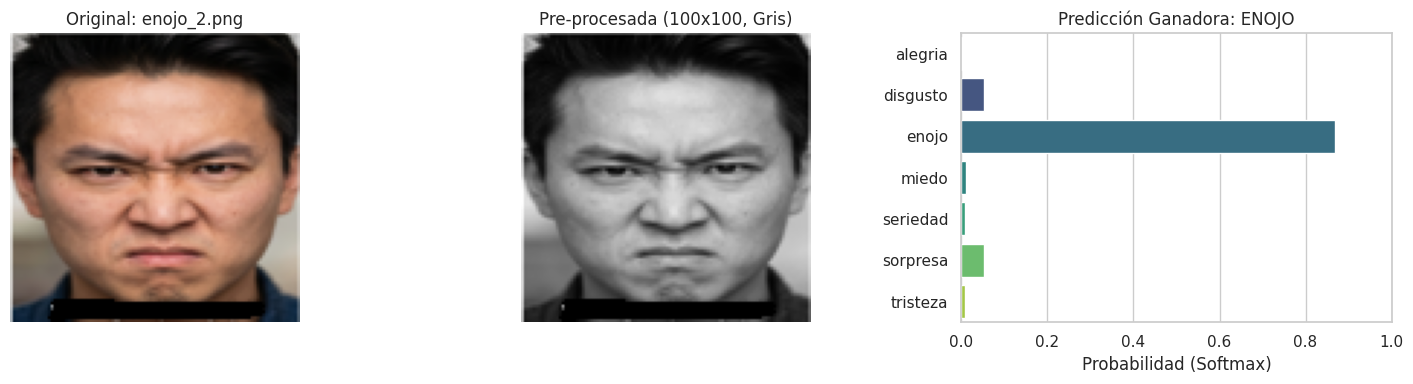

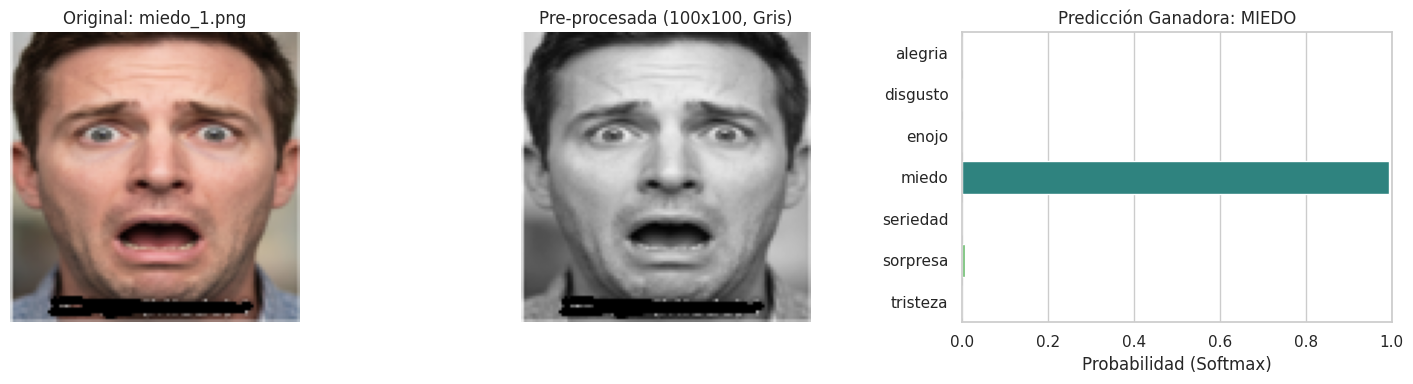

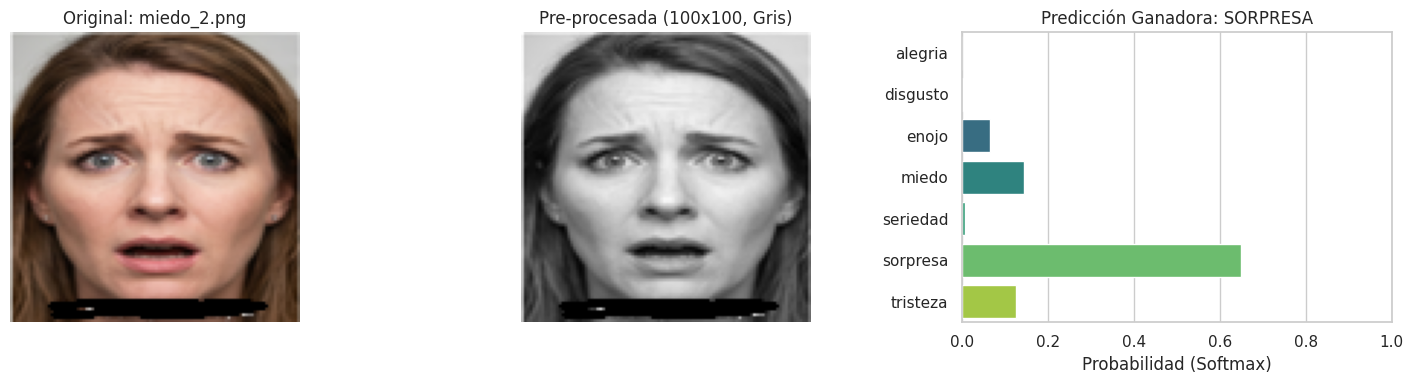

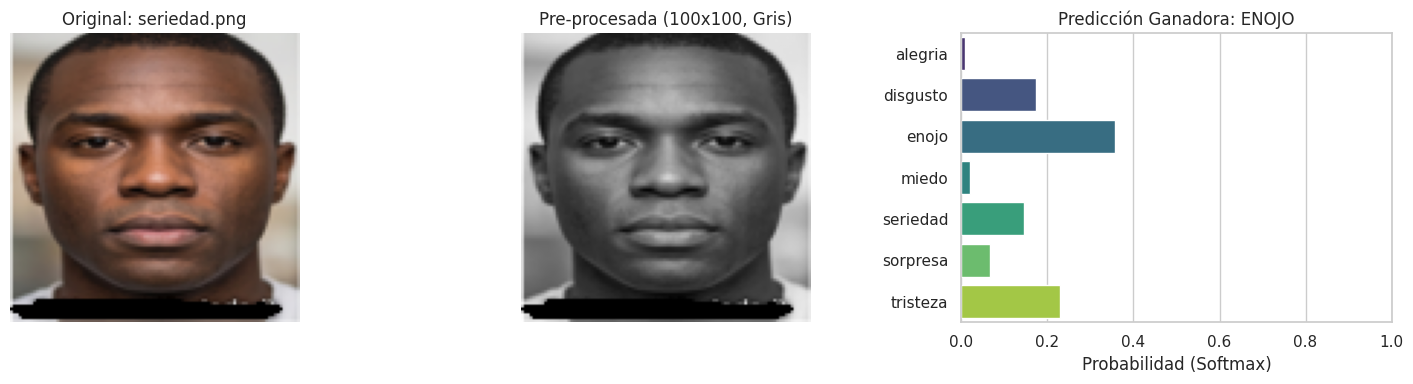

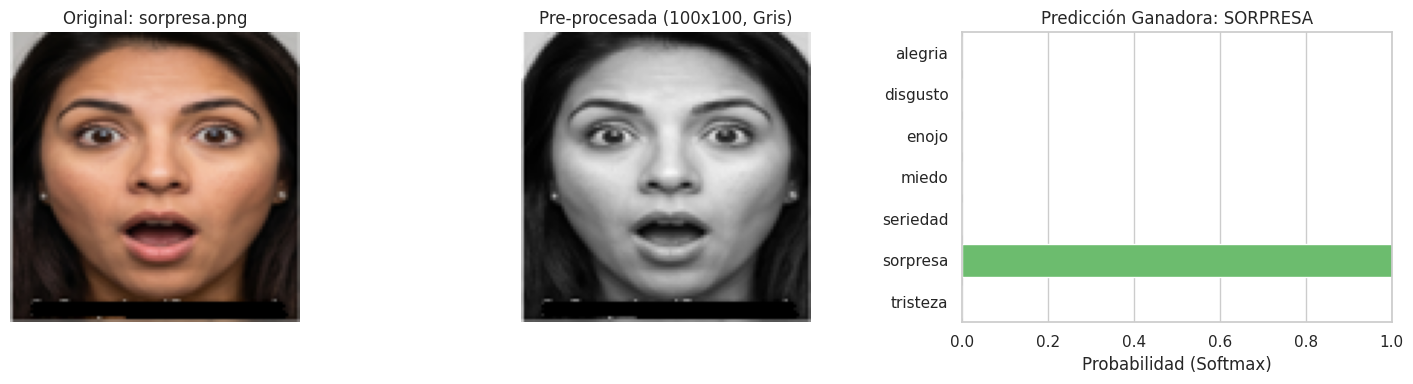

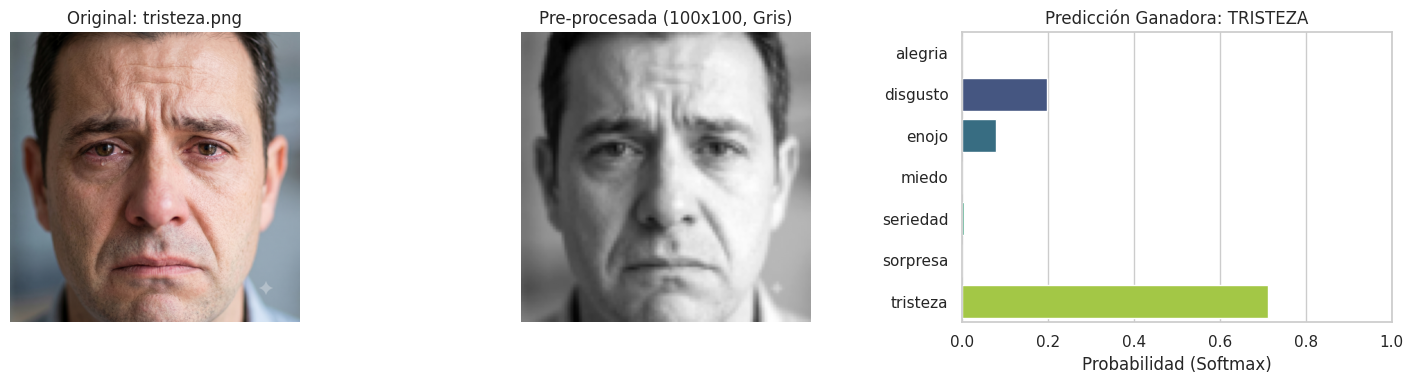

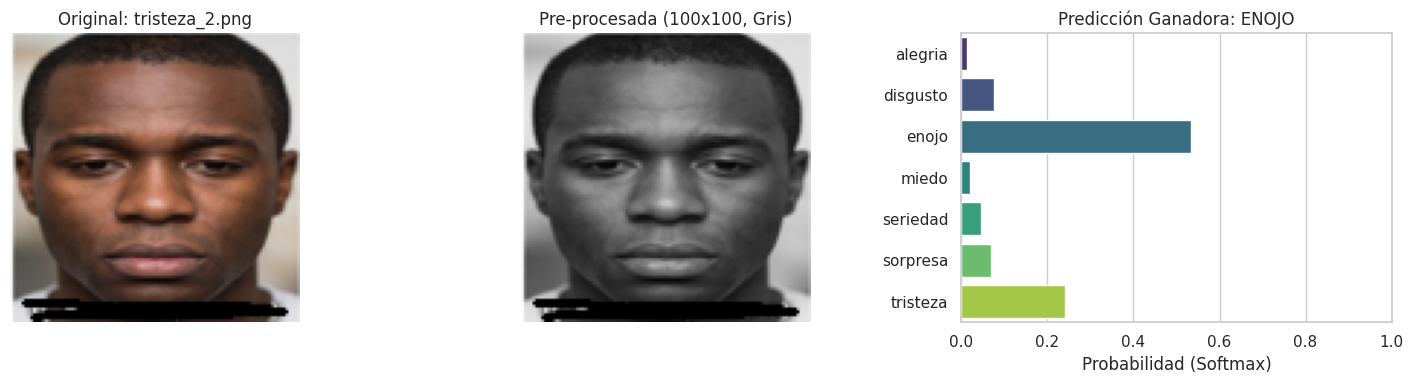

In [33]:
ruta_nuevas = '/content/nuevas_imagenes'
imagenes = sorted([f for f in os.listdir(ruta_nuevas) if f.endswith(('.png', '.jpg', '.jpeg'))])

# Transformaciones para test/inferencia (igual que en validación)
transforms_inferencia = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

modelo.eval()

print("--- EVALUACIÓN DE IMÁGENES NUEVAS ---")

for img_name in imagenes:
    img_path = os.path.join(ruta_nuevas, img_name)
    img_orig = Image.open(img_path).convert('RGB')

    # Aplicar preprocesamiento
    img_tensor = transforms_inferencia(img_orig)

    # Desnormalizar para visualizar la imagen pre-procesada de forma correcta
    img_vis = img_tensor.clone()
    img_vis = img_vis * STD[0] + MEAN[0]
    img_vis = img_vis.squeeze().numpy()

    # Inferencia
    with torch.no_grad():
        # Agregamos dimensión de batch y enviamos al device
        input_tensor = img_tensor.unsqueeze(0).to(device)
        output = modelo(input_tensor)
        # Normalizamos los scores usando Softmax (0 a 1)
        probs = F.softmax(output, dim=1).squeeze().cpu().numpy()

    clase_pred = clases[np.argmax(probs)]

    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Imagen Original
    axes[0].imshow(img_orig)
    axes[0].set_title(f"Original: {img_name}")
    axes[0].axis('off')

    # 2. Imagen Pre-procesada
    axes[1].imshow(img_vis, cmap='gray')
    axes[1].set_title("Pre-procesada (100x100, Gris)")
    axes[1].axis('off')

    # 3. Scores de Predicción (Corregido el FutureWarning)
    sns.barplot(x=probs, y=clases, ax=axes[2], palette="viridis", hue=clases, legend=False)
    axes[2].set_title(f"Predicción Ganadora: {clase_pred.upper()}")
    axes[2].set_xlabel('Probabilidad (Softmax)')
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

### 4.1 Conclusiones

- Solo 7 de las 12 imagenes se clasificaron correctamente
- Una de las imagenes de alegria (clase con mas imagenes que el resto) la clasifico como enojo, y con un mas de 95% de confianza. Se ve que en enojo aprendio algun patron que se repite en alegria
- Sin embargo las dos imagenes de enojo las clasifico bien, y con mucha confianza
- Las imagenes disgusto se clasifican como disgusto o enojo. El clasificador no entiende bien la clase disgusto
- Las imagenes de enojo se clasificaron ambas bien, y con mucha confianza. Se ve que los rasgos de enojo son muy particulares (ceño fruncido, etc)
- Miedo se confunde con sorpresa, seguramente por la boca suele estar abierta en ambas emociones
- Tambien le cuesta clasificar correctamente la expresion de seriedad, se ve que porque no tiene nigun rango distintivo (ninguna de las clasees obtiene mas de un 40% en la softmax)

 ## 5 Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

--- DETECCIÓN DE ROSTROS E INFERENCIA ---


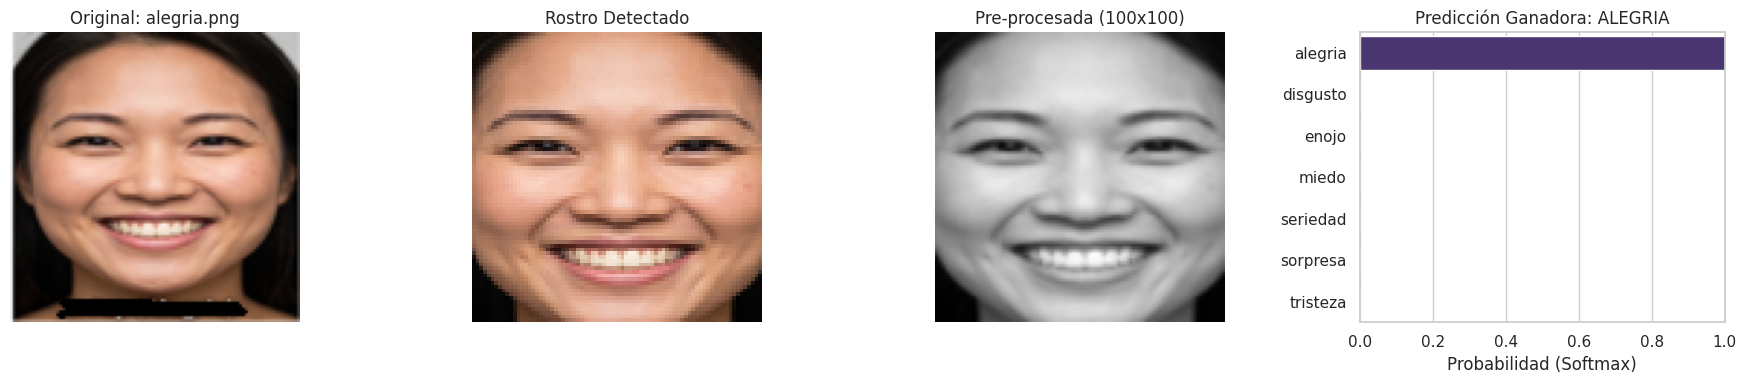

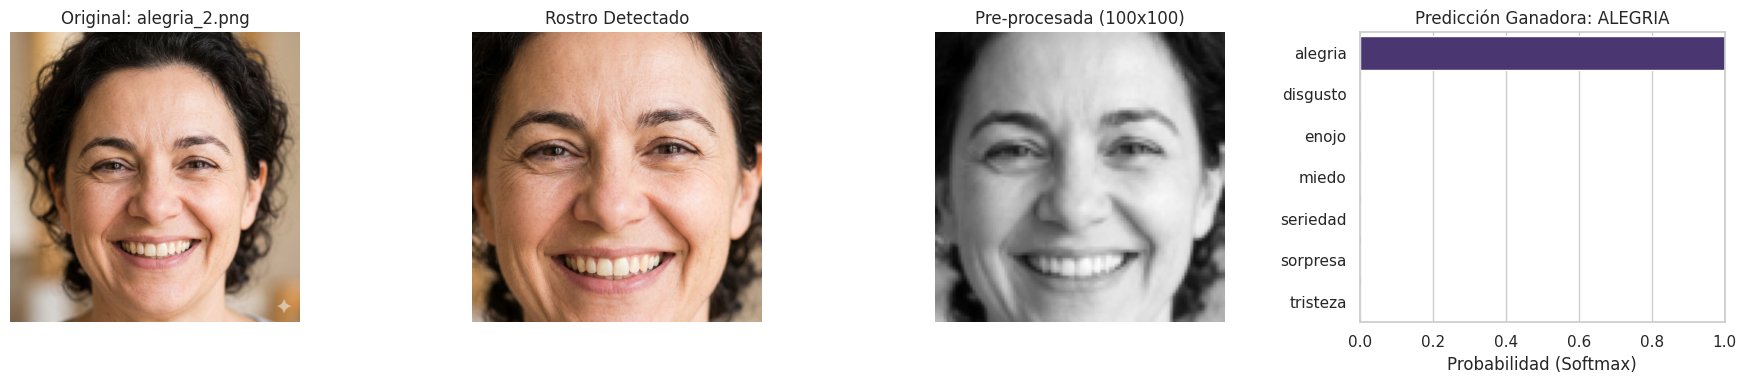

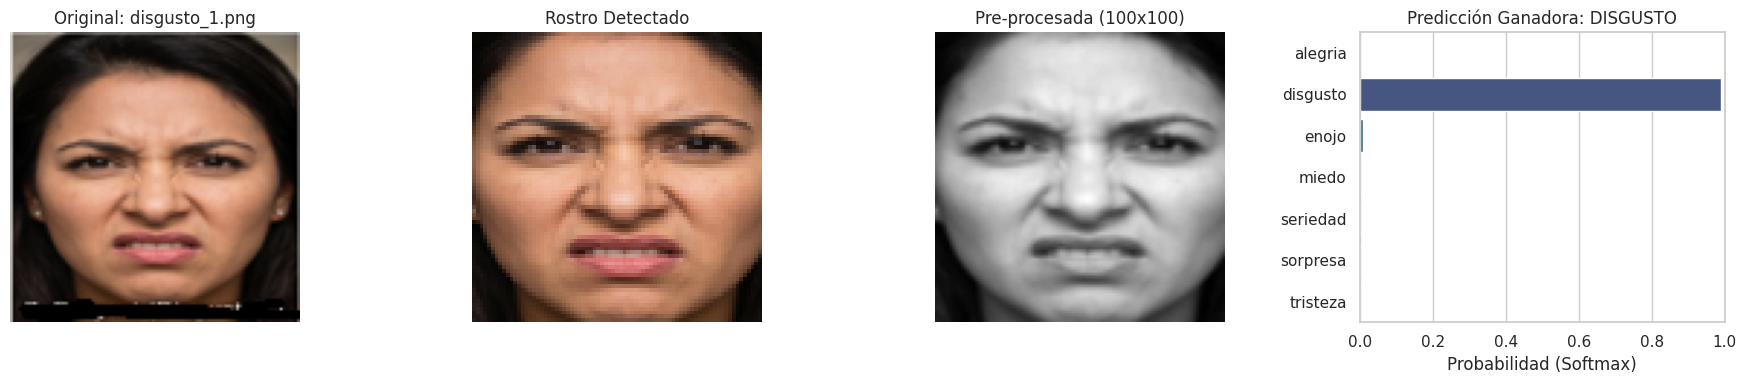

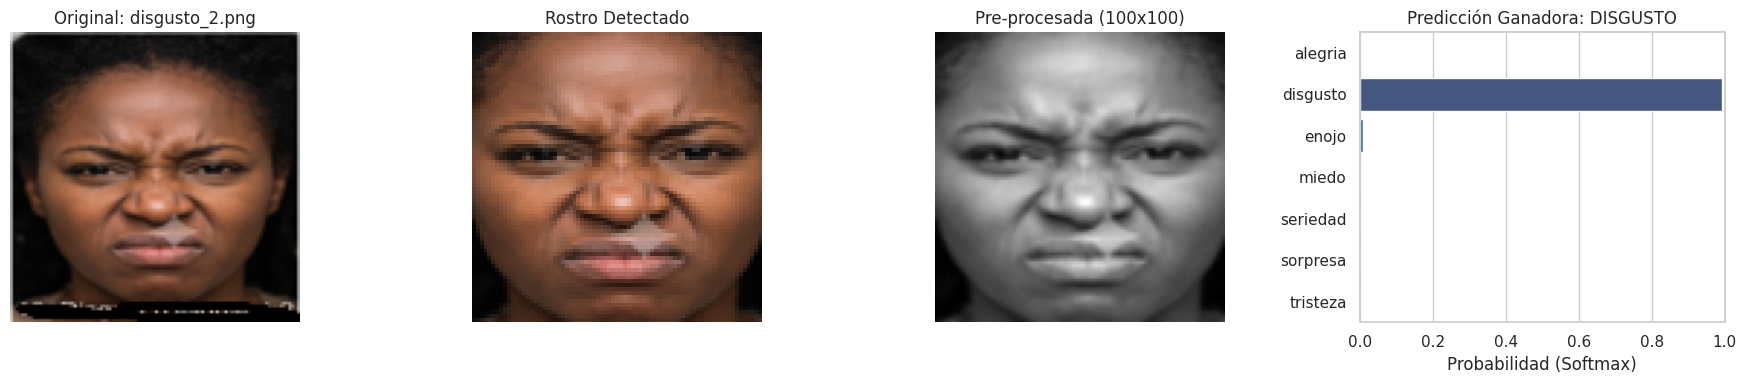

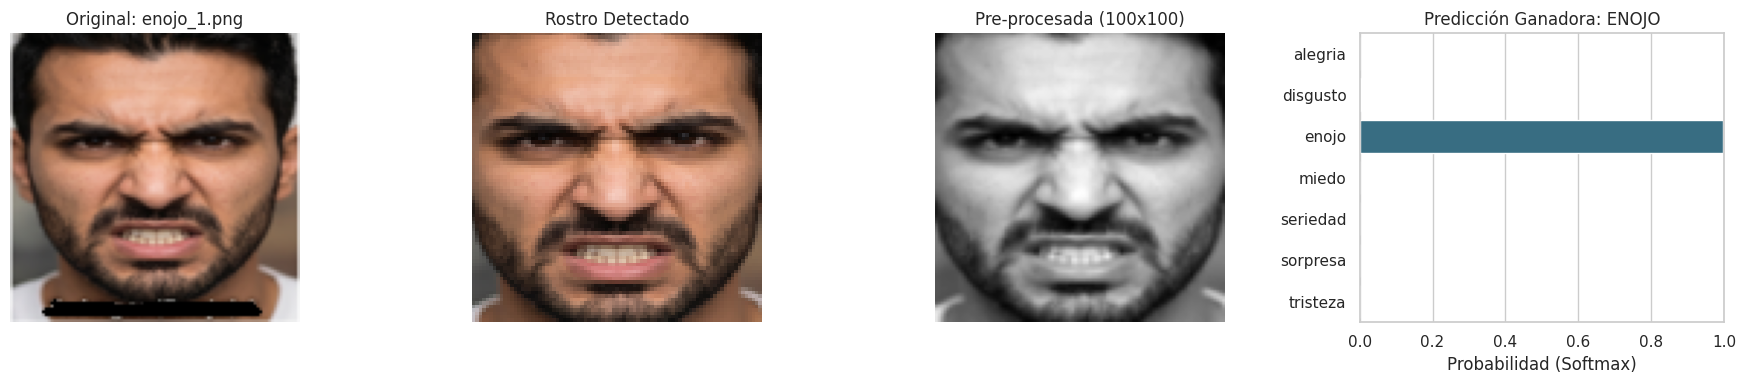

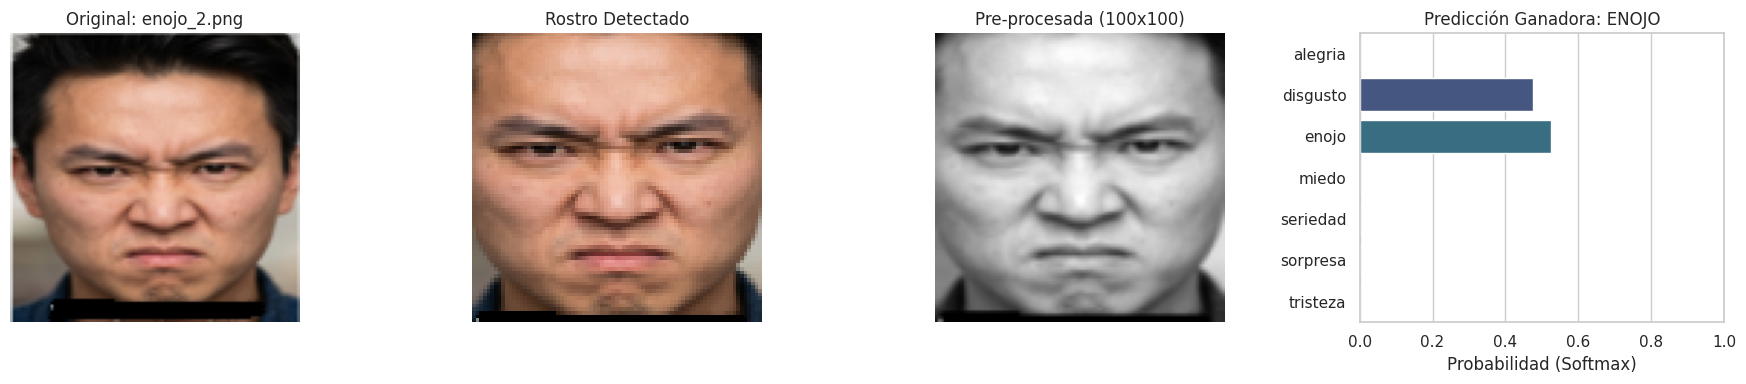

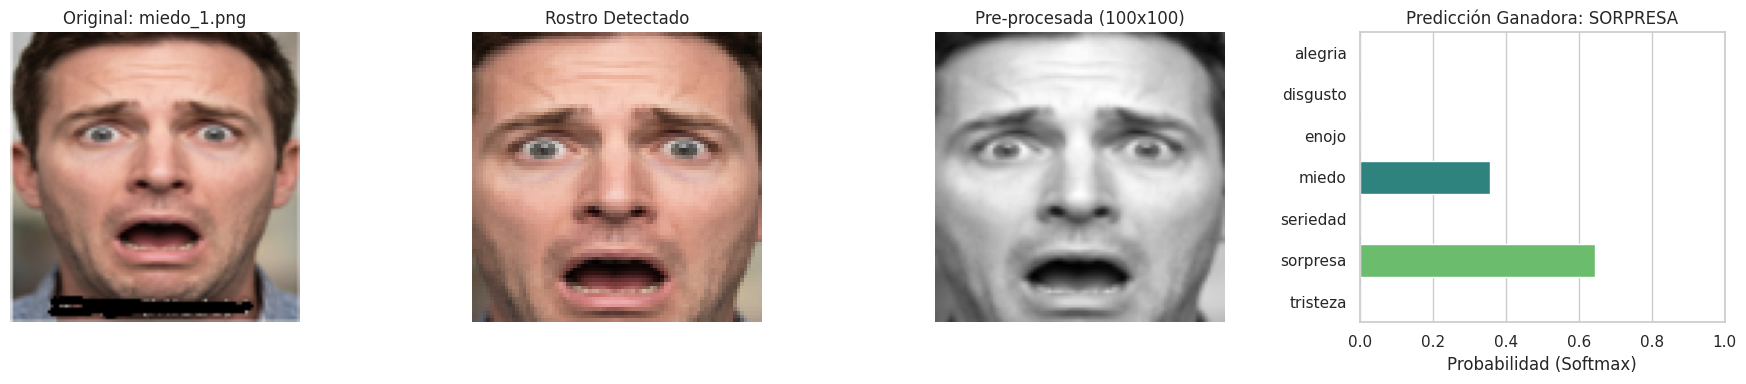

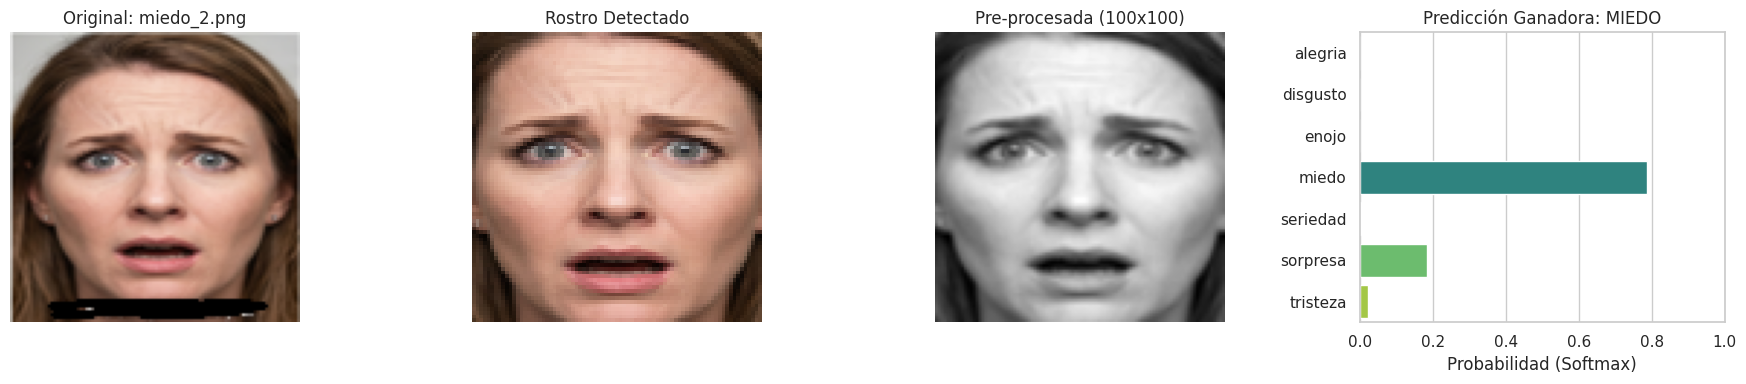

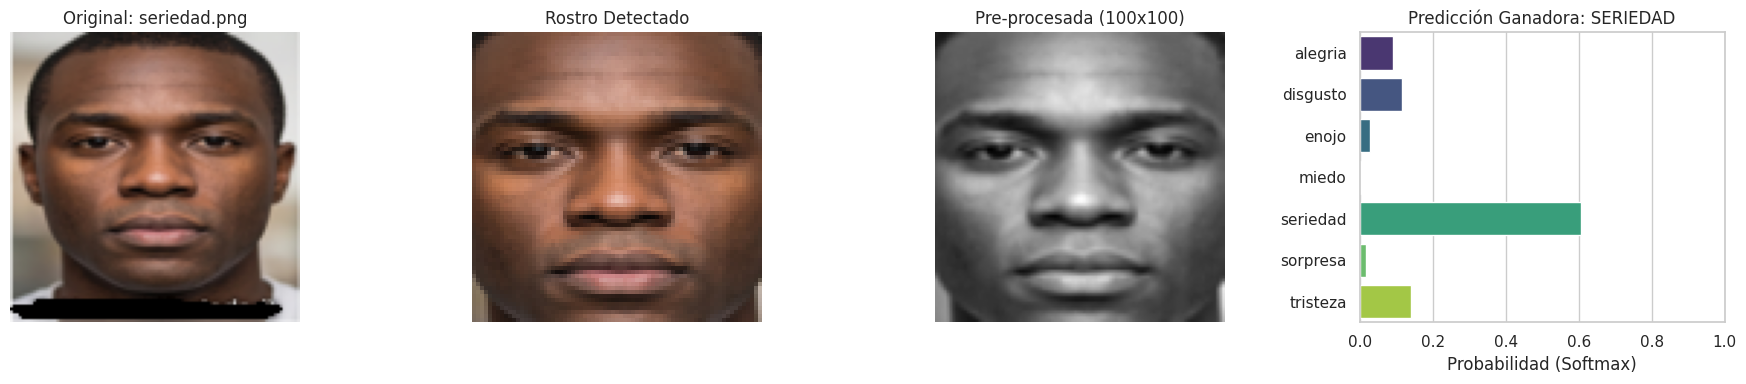

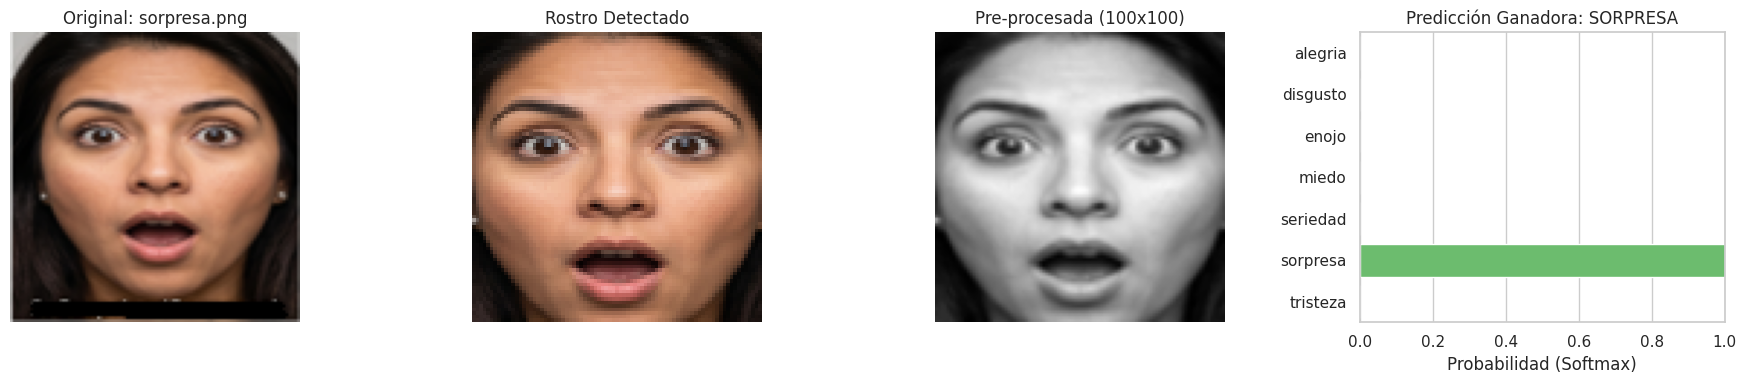

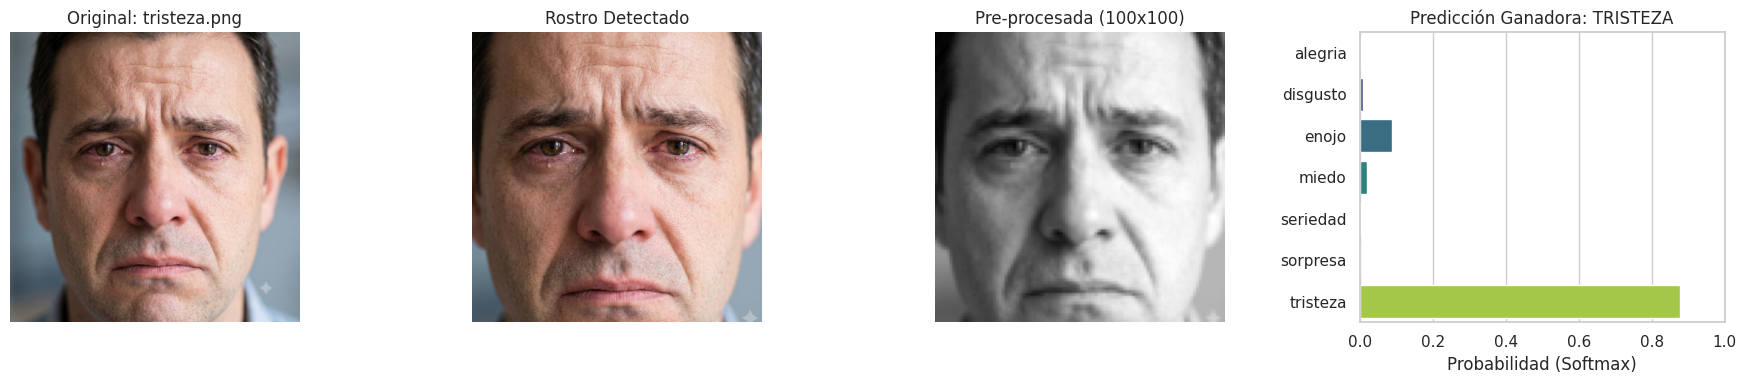

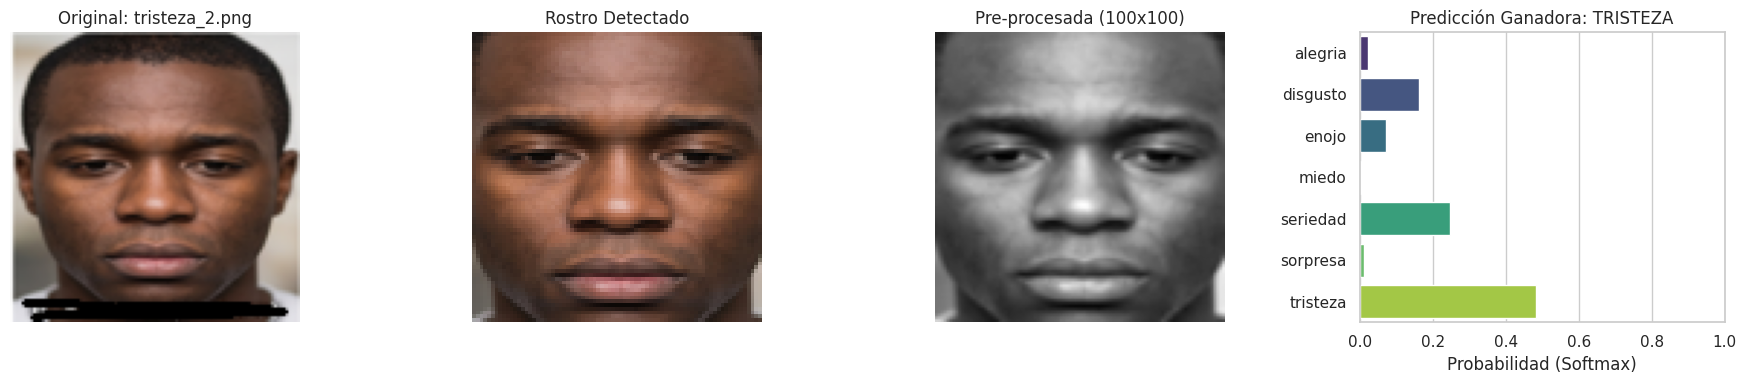

In [34]:
# Como el TP no indica nada, usamos el detector de rostros pre-entrenado de OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. Reutilizar transformaciones de inferencia (las mismas de validación)
transforms_inferencia = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

ruta_nuevas = '/content/nuevas_imagenes'
imagenes = sorted([f for f in os.listdir(ruta_nuevas) if f.endswith(('.png', '.jpg', '.jpeg'))])

modelo.eval()
print("--- DETECCIÓN DE ROSTROS E INFERENCIA ---")

for img_name in imagenes:
    img_path = os.path.join(ruta_nuevas, img_name)

    # Leer imagen con OpenCV para la detección (BGR a RGB)
    img_cv = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # Detectar rostros (puedes ajustar scaleFactor, minNeighbors, minSize si alguna falla)
    rostros = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Si no detecta rostros, mostramos un aviso y pasamos a la siguiente
    if len(rostros) == 0:
        print(f"⚠️ No se detectó rostro en: {img_name}")
        continue

    # Tomar el primer rostro detectado (asumiendo 1 persona por foto)
    x, y, w, h = rostros[0]

    # Recortar el rostro original (agregando un pequeño margen si lo deseas)
    rostro_recortado = img_rgb[y:y+h, x:x+w]

    # Convertir el recorte de array NumPy a imagen PIL para aplicar transforms
    rostro_pil = Image.fromarray(rostro_recortado)

    # Pre-procesamiento de la imagen recortada para el modelo
    img_tensor = transforms_inferencia(rostro_pil)

    # Desnormalizar para visualizar correctamente
    img_vis = img_tensor.clone()
    img_vis = img_vis * STD[0] + MEAN[0]
    img_vis = img_vis.squeeze().numpy()

    # Inferencia
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(device)
        output = modelo(input_tensor)
        probs = F.softmax(output, dim=1).squeeze().cpu().numpy()

    clase_pred = clases[np.argmax(probs)]

    # Visualización
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # A. Imagen Original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original: {img_name}")
    axes[0].axis('off')

    # B. Rostro Recortado
    axes[1].imshow(rostro_recortado)
    axes[1].set_title("Rostro Detectado")
    axes[1].axis('off')

    # C. Imagen Pre-procesada (la que va al modelo)
    axes[2].imshow(img_vis, cmap='gray')
    axes[2].set_title("Pre-procesada (100x100)")
    axes[2].axis('off')

    # D. Probabilidades
    sns.barplot(x=probs, y=clases, ax=axes[3], palette="viridis", hue=clases, legend=False)
    axes[3].set_title(f"Predicción Ganadora: {clase_pred.upper()}")
    axes[3].set_xlabel('Probabilidad (Softmax)')
    axes[3].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

### 5.1 Conclusiones Finales

* Efectividad del Recorte: Recortar el rostro previo al pre-procesamiento mejora la inferencia al remover ruido del fondo y centrar las facciones clave. El modelo es más preciso al enfocarse únicamente en el rostro, a diferencia del enfoque del Punto 4 donde los bordes y cuellos podían alterar la posición de los ojos y boca durante el Resize
* Aplicando el filtro del rostro la clasificacion de imagenes nuevas mejoro considerablemnte, 11 de 12 estuvieron bien clasificadas
* Emociones como sorpresa y miedo se caracterizan por tener la boca abierta, lo que confunde al clasificador
* Lo mismo pasa con disgusto y enojom ambas se caracterizan por el ceño fruncido
* Conclusion: Tanto en datos tabulares como aqui, el preprocesamiento es FUNDAMENTAL. Elimnar el ruido (en este caso el fondo, cuando aplicamos el filtro de rostros) ayuda mucho al modelo. Garbage in garbage out